<!--
  ============================================================================
  laplace_simulations.ipynb  —  reproducibility notebook
  Section M.1 of the Supplementary Materials
  ============================================================================
-->

<h1 align="center">Laplace Type I SSG Likelihood Simulations</h1>

<p align="center">
  <b>Reproducibility for Experiments E1 and E2 and the ELBO trajectories of Section M.1 of the Supplementary Materials</b><br>
  <i>TAVIE-SSG vs. ADVI (mean-field &amp; full-rank) &middot; DADVI &middot; PyMC (NUTS)</i>
</p>

<p align="center">
  <img alt="Python" src="https://img.shields.io/badge/Python-3.9-3776AB?logo=python&logoColor=white">
  <img alt="Jupyter" src="https://img.shields.io/badge/Jupyter-Notebook-F37626?logo=jupyter&logoColor=white">
  <img alt="PyMC" src="https://img.shields.io/badge/PyMC-5.x-1E4C7E">
  <img alt="JAX" src="https://img.shields.io/badge/JAX-x64-8A2BE2">
</p>

<p align="center">
  <a href="https://github.com/Roy-SR-007/TAVIE-SSG/blob/main/laplace_simulations.ipynb"><img alt="nbviewer" src="https://img.shields.io/badge/render-nbviewer-F37726?logo=jupyter&logoColor=white"></a>
  <img alt="Data" src="https://img.shields.io/badge/data-simulated-005EA2">
</p>

---

### What this notebook does

This notebook comprises the Laplace Type I SSG likelihood experiments, namely

1. Experiments **E1** and **E2** in Section M.1 of the Supplementary Materials — MSEs of
   the parameter estimates, runtimes, and sliced-Wasserstein distances;
2. the **ELBO trajectory** plots, also in Section M.1 of the Supplementary Materials.

Data are simulated from a Laplace regression, and **TAVIE-SSG** is compared against four
competitors over independent replicates.

| | Specification |
|:--|:--|
| **Model** | $y \sim \mathrm{Laplace}\!\left(\mu = X\boldsymbol\beta,\ b = 1/\sqrt{\tau^{2}}\right)$ |
| **Priors** | $\boldsymbol\beta \sim \mathcal{N}(0, 1)$, $\tau^{2} \sim \mathrm{Gamma}(a_0/2,\ b_0/2)$ with $a_0 = b_0 = 0.05$ |
| **Truth** | $\tau^{2}_{0} = 3.0$, $\boldsymbol\beta_{0}$ drawn from $\mathcal{N}(0, 1)$ |
| **Experiment E1** | fixed $p = 9$, $n \in \{200, 500, 1000, 2000\}$, 100 replicates |
| **Experiment E2** | fixed $n = 1000$, $p \in \{4, 9, 16, 21\}$, 100 replicates |
| **Methods** | TAVIE-SSG, ADVI (MF), ADVI (FR), DADVI, PyMC (NUTS) |
| **Metrics** | $p^{-1}\lVert \boldsymbol\beta_0 - \hat{\boldsymbol\beta}\rVert_{2}^{2}$, $(\tau^{2}_0 - \hat{\tau}^{2})^2$, wall-clock runtime, and sliced-Wasserstein distance to the PyMC (NUTS) posterior |

> [!IMPORTANT]
> **To reproduce, run every cell in order, top to bottom.**

### Results generated in this notebook

| Main Manuscript | Supplementary Materials | Output file |
|:--:|:--:|:--|
| — | **Figure 23** | `Laplace_MSE_boxplots_multi_n_p_8.pdf` |
| — | **Figure 24** | `Laplace_SW_boxplots_multi_n_p_8_logscale.pdf` |
| — | **Figure 25** | `Laplace_MSE_boxplots_multi_p_n_1000.pdf` |
| — | **Figure 26** | `runtime_Laplace_multi_n_multi_p.pdf` |
| — | **Figure 27** | `Laplace_ELBO_n_1000_p_8.pdf` |

All figures are written to `results_compete/plots/`, and the intermediate result files to
`results_compete/`.

### Required Imports for TAVIE-SSG and Competitors

In [ ]:
# imports required
# setup the dadvi module following https://github.com/martiningram/dadvi
import pymc as pm
import pytensor
import pytensor.tensor as pt
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import jax
import jax.numpy as jnp
setattr(jnp, "product", jnp.prod)
jax.config.update("jax_enable_x64", True)
from CompetingMethods import *
from dadvi.pymc.jax_api import fit_pymc_dadvi_with_jax
from TAVIE import *
import rich
from sklearn.preprocessing import scale
from IPython.display import display, Latex
from time import perf_counter
from tqdm import tqdm, trange
from scipy.stats import t
import arviz as az
import re

### Laplace PyMC model and NUTS

In [ ]:
def laplace_pymc_model(X, y, a0=0.05, b0=0.05):
    """
    Build and return a PyMC Laplace regression model:
        y ~ Laplace(mu = X @ beta, b)

    Parameters
    ----------
    X : array-like, shape (n,) or (n, p)
    y : array-like, shape (n,)

    Returns
    -------
    model : pm.Model
    """
    # Ensure arrays & shapes
    X = np.asarray(X)
    y = np.asarray(y)
    if X.ndim == 1:
        X = X.reshape(-1, 1)

    n, p = X.shape
    dtype = np.dtype(pytensor.config.floatX)

    with pm.Model() as model:
        # Data containers (so you can update later if you want)
        X_data = pm.MutableData("X", X.astype(dtype))
        y_data = pm.MutableData("y", y.astype(dtype))

        # Priors
        beta = pm.Normal("beta", mu=0.0, sigma=1.0, shape=p)
        tau2 = pm.Gamma("tau2", alpha=a0/2, beta=b0/2)

        # Linear predictor
        mu = pt.dot(X_data, beta)

        # Laplace likelihood
        pm.Laplace("y_obs", mu=mu, b=1/np.sqrt(tau2), observed=y_data)

    return model

def fit_NUTS_laplace(model):
    
    import logging, warnings
    # Mute PyMC/pytensor logs + warnings
    logging.getLogger("pymc").setLevel(logging.ERROR)
    logging.getLogger("pytensor").setLevel(logging.ERROR)
    warnings.filterwarnings("ignore", message=r"os\.fork\(\) was called", category=RuntimeWarning)

    # fitting the NUTS model
    with model as model:
        nuts_model = pm.sample(progressbar=False, compute_convergence_checks=False)

    # pulling the summary from nuts_model
    summ = az.summary(nuts_model, var_names=["beta", "tau2"])[["mean"]]

    # tau2 mean (scalar)
    tau2_mean = float(summ.loc[summ.index == "tau2", "mean"].values[0])
    
    # beta mean (scalar or vector)
    beta_rows = summ[summ.index.str.startswith("beta")]
    if len(beta_rows) == 1 and beta_rows.index[0] == "beta":
        beta_mean = float(beta_rows["mean"].iloc[0])
    else:
        # sort beta[0], beta[1], … numerically
        def _idx(name):
            m = re.match(r"beta\[(\d+)\]", name)
            return int(m.group(1)) if m else 0
        beta_mean = (
            beta_rows.assign(_i=beta_rows.index.map(_idx))
                     .sort_values("_i")["mean"]
                     .to_numpy()
        )

    # storing the posterior means of the parameters
    post_means = {"beta": np.array(beta_mean), "tau2": tau2_mean}
    
    return post_means

### Experiment E1: fixed $p=9$ (includes intercept) and $n\in \{200, 500, 1000, 2000\}$

Recording $p^{-1}\lVert \beta_0 - \hat{\beta}\rVert_{2}^{2}$ and $(\tau_0^{2} - \hat{\tau}^{2})^2$. The results are stored in `results_compete/Laplace_metrics_multi_n_p_8.pkl`.

In [ ]:
# ==== Experiment settings ====
total_p = 9 # p = total_p - 1
p = 8
tau2_true = 3.0
num_reps = 100
sample_sizes = [200, 500, 1000, 2000]     # <-- your various n’s here

# True beta vector
beta_true = np.random.normal(loc=0.0, scale=1.0, size=p+1)

# Prior for full‐cov BBVI
Sigma_prior = np.eye(p + 1)
a, b = 0.025, 0.025

# Pre‐allocate storage: shape (len(sample_sizes), num_reps)
n_sizes = len(sample_sizes)
mse_beta_TAVIE          = np.zeros((n_sizes, num_reps))
mse_tau2_TAVIE          = np.zeros((n_sizes, num_reps))
time_TAVIE              = np.zeros((n_sizes, num_reps))

mse_beta_DADVI          = np.zeros((n_sizes, num_reps))
mse_tau2_DADVI          = np.zeros((n_sizes, num_reps))
time_DADVI              = np.zeros((n_sizes, num_reps))

mse_beta_NUTS          = np.zeros((n_sizes, num_reps))
mse_tau2_NUTS          = np.zeros((n_sizes, num_reps))
time_NUTS              = np.zeros((n_sizes, num_reps))

mse_beta_ADVI_mf           = np.zeros((n_sizes, num_reps))
mse_tau2_ADVI_mf           = np.zeros((n_sizes, num_reps))
time_ADVI_mf               = np.zeros((n_sizes, num_reps))

mse_beta_ADVI_fr   = np.zeros((n_sizes, num_reps))
mse_tau2_ADVI_fr   = np.zeros((n_sizes, num_reps))
time_ADVI_fr       = np.zeros((n_sizes, num_reps))

# Initialize TAVIE once
laplace_tavie_model = TAVIE_loc_scale(family="laplace", fit_intercept=True)

# ==== Main loops ====
for i, n in enumerate(sample_sizes):
    for rep in trange(num_reps, desc=f"n={n}"):
        np.random.seed(rep)
        # 1) Simulate data
        X = np.random.normal(size=(n, p))
        X_bbvi = np.column_stack([np.ones(n), X])
        error = np.random.laplace(loc=0.0, scale=1/np.sqrt(tau2_true), size=n)
        y = X_bbvi @ beta_true + error

        # ---- TAVIE ----
        t0 = perf_counter()
        laplace_tavie_model.fit(X, y, verbose=False)
        time_TAVIE[i, rep] = perf_counter() - t0
        beta_est_TAVIE, tau2_est_TAVIE = laplace_tavie_model.get_TAVIE_means(verbose=False)
        mse_beta_TAVIE[i, rep] = np.mean((beta_est_TAVIE - beta_true)**2)
        mse_tau2_TAVIE[i, rep] = (tau2_est_TAVIE - tau2_true)**2

        # DADVI estimator
        laplace_dadvi_model = laplace_pymc_model(X_bbvi, y)
        t0 = perf_counter()
        laplace_dadvi_res = fit_pymc_dadvi_with_jax(laplace_dadvi_model, num_fixed_draws=30).get_posterior_means()
        time_DADVI[i, rep] = perf_counter() - t0
        beta_est_DADVI = laplace_dadvi_res['beta']
        tau2_est_DADVI = np.exp(laplace_dadvi_res['tau2_log__'])
        mse_beta_DADVI[i, rep] = np.mean((beta_est_DADVI - beta_true)**2)
        mse_tau2_DADVI[i, rep] = (tau2_est_DADVI - tau2_true)**2
    
        # NUTS estimator
        t0 = perf_counter()
        laplace_nuts_res = fit_NUTS_laplace(laplace_dadvi_model)
        time_NUTS[i, rep] = perf_counter() - t0
        beta_est_NUTS = laplace_nuts_res['beta']
        tau2_est_NUTS = laplace_nuts_res['tau2']
        mse_beta_NUTS[i, rep] = np.mean((beta_est_NUTS - beta_true)**2)
        mse_tau2_NUTS[i, rep] = (tau2_est_NUTS - tau2_true)**2

        # ---- ADVI mean-field ----
        t0 = perf_counter()
        res_diag = BBVI_Laplace_patience_best(
            X_bbvi, y,
            a=a, b=b,
            lr=1e-3,
            tol=1e-9,
            patience=1e4,
            verbose=False
        )
        time_ADVI_mf[i, rep] = perf_counter() - t0
        beta_d = res_diag['beta_mean']
        tau2_d = res_diag['tau2_mean']
        mse_beta_ADVI_mf[i, rep] = np.mean((beta_d - beta_true)**2)
        mse_tau2_ADVI_mf[i, rep] = (tau2_d - tau2_true)**2

        # ---- ADVI full-rank ----
        t0 = perf_counter()
        res_full = BBVI_Laplace_fullcov_AdamW_best(
            X_bbvi, y,
            Sigma_prior=Sigma_prior,
            a=a, b=b,
            lr=1e-3,
            tol=1e-9,
            patience=1e4,
            verbose=False
        )
        time_ADVI_fr[i, rep] = perf_counter() - t0

        beta_f = res_full['beta_mean']
        tau2_f = res_full['tau2_mean']
        mse_beta_ADVI_fr[i, rep] = np.mean((beta_f - beta_true)**2)
        mse_tau2_ADVI_fr[i, rep] = (tau2_f - tau2_true)**2

# saving the metrics
import pickle

# collect everything into a single dict
metrics_df = {
    'p'            :       p,
    'n'            :       sample_sizes,
    'mse_beta_TAVIE':     mse_beta_TAVIE,
    'mse_tau2_TAVIE':     mse_tau2_TAVIE,
    'time_TAVIE':         time_TAVIE,
    'mse_beta_ADVI_mf':      mse_beta_ADVI_mf,
    'mse_tau2_ADVI_mf':      mse_tau2_ADVI_mf,
    'time_ADVI_mf':          time_ADVI_mf,
    'mse_beta_ADVI_fr':      mse_beta_ADVI_fr,
    'mse_tau2_ADVI_fr':      mse_tau2_ADVI_fr,
    'time_ADVI_fr':          time_ADVI_fr,
    'mse_beta_DADVI':      mse_beta_DADVI,
    'mse_tau2_DADVI':      mse_tau2_DADVI,
    'time_DADVI':          time_DADVI,
    'mse_beta_NUTS':      mse_beta_NUTS,
    'mse_tau2_NUTS':      mse_tau2_NUTS,
    'time_NUTS':          time_NUTS,
}

# write to disk
with open(f'results_compete/Laplace_metrics_multi_n_p_{p}.pkl', 'wb') as f:
    pickle.dump(metrics_df, f, protocol=pickle.HIGHEST_PROTOCOL)

### Under Experiment E1, SW distance for Laplace Type I SSG likelihood

SW distance between PyMC (NUTS) approximation of the true posterior and TAVIE-SSG/ADVI (MF)/ADVI (FR)/DADVI. Results are in `results_compete/sw_compare_methods_alpha_1.0_p_8.csv` and `results_compete/sw_compare_methods_alpha_1.0_p_8.pkl`.

In [2]:
# required imports

import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from time import perf_counter
from tqdm.auto import trange
import pymc as pm
import pytensor
import pytensor.tensor as pt
from matplotlib.patches import Patch
import jax
import jax.numpy as jnp
setattr(jnp, "product", jnp.prod)
jax.config.update("jax_enable_x64", True)
from CompetingMethods import *
from dadvi.pymc.jax_api import fit_pymc_dadvi_with_jax
from TAVIE import *
import rich
from sklearn.preprocessing import scale
from IPython.display import display, Latex
from time import perf_counter
from tqdm import tqdm, trange
from scipy.stats import t
import arviz as az
import re

In [ ]:
# ============================================================
# SETTINGS
# ============================================================
total_p = 9  # p = total_p - 1
p = 8
tau2_true = 3.0
alpha = 1.0

sample_sizes = [200, 500, 1000, 2000]
num_reps = 10

nuts_draws = 4000
nuts_tune = 1000
nuts_chains = 2
nuts_target_accept = 0.9

n_proj = 500

Sigma_prior = np.eye(p + 1)
a = 0.025
b = 0.025

output_dir = "results_compete"
os.makedirs(output_dir, exist_ok=True)

np.random.seed(123)
beta_true = np.random.normal(loc=0.0, scale=1.0, size=p + 1)


# ============================================================
# DATA GENERATION
# ============================================================
def generate_laplace_regression_data(n, p, beta_true, tau2_true, seed=None):
    rng = np.random.default_rng(seed)
    X = rng.normal(size=(n, p))
    error = rng.laplace(loc=0.0, scale=1.0 / np.sqrt(tau2_true), size=n)
    y = beta_true[0] + X @ beta_true[1:] + error
    return X, y


# ============================================================
# PYMC MODEL FOR TRUE POSTERIOR
# ============================================================
def laplace_fractional_pymc_model(X, y, alpha, prior_var=10.0, a0=0.005, b0=0.005):
    X = np.asarray(X)
    y = np.asarray(y)

    if X.ndim == 1:
        X = X.reshape(-1, 1)

    n_local, p_local = X.shape
    X_with_intercept = np.column_stack((np.ones(n_local), X))

    dtype = np.dtype(pytensor.config.floatX)
    X_with_intercept = X_with_intercept.astype(dtype)
    y = y.astype(dtype)

    with pm.Model() as model:
        X_data = pm.Data("X_data", X_with_intercept)
        y_data = pm.Data("y_data", y)

        beta = pm.Normal("beta", mu=0.0, sigma=np.sqrt(prior_var), shape=p_local + 1)
        tau2 = pm.Gamma("tau2", alpha=a0 / 2.0, beta=b0 / 2.0)

        mu = pt.dot(X_data, beta)
        b_scale = 1.0 / pt.sqrt(tau2)

        loglik_vec = pm.logp(pm.Laplace.dist(mu=mu, b=b_scale), y_data)
        pm.Potential("frac_loglik", alpha * pt.sum(loglik_vec))

    return model


def laplace_fractional_pymc_model_with_intercept_design(
    X_bbvi, y, alpha=1.0, prior_var=10.0, a0=0.005, b0=0.005
):
    X_bbvi = np.asarray(X_bbvi)
    y = np.asarray(y)

    dtype = np.dtype(pytensor.config.floatX)
    X_bbvi = X_bbvi.astype(dtype)
    y = y.astype(dtype)

    n_local, p1 = X_bbvi.shape

    with pm.Model() as model:
        X_data = pm.Data("X_data", X_bbvi)
        y_data = pm.Data("y_data", y)

        beta = pm.Normal("beta", mu=0.0, sigma=np.sqrt(prior_var), shape=p1)
        tau2 = pm.Gamma("tau2", alpha=a0 / 2.0, beta=b0 / 2.0)

        mu = pt.dot(X_data, beta)
        b_scale = 1.0 / pt.sqrt(tau2)

        loglik_vec = pm.logp(pm.Laplace.dist(mu=mu, b=b_scale), y_data)
        pm.Potential("frac_loglik", alpha * pt.sum(loglik_vec))

    return model


# ============================================================
# NUTS FIT
# ============================================================
def fit_NUTS_laplace_fractional(
    model,
    draws=4000,
    tune=1000,
    chains=2,
    target_accept=0.9,
    random_seed=123
):
    with model:
        idata = pm.sample(
            draws=draws,
            tune=tune,
            chains=chains,
            cores=1,
            target_accept=target_accept,
            progressbar=False,
            compute_convergence_checks=False,
            random_seed=random_seed,
            return_inferencedata=True
        )
    return idata


def extract_true_posterior_z_samples(idata):
    beta_draws = idata.posterior["beta"].stack(sample=("chain", "draw")).values
    tau2_draws = idata.posterior["tau2"].stack(sample=("chain", "draw")).values

    if beta_draws.shape[0] < beta_draws.shape[1]:
        beta_draws = beta_draws.T

    tau2_draws = np.asarray(tau2_draws).reshape(-1)
    log_tau2 = np.log(tau2_draws)

    z = np.column_stack([beta_draws, log_tau2])
    return z


# ============================================================
# SLICED WASSERSTEIN
# ============================================================
def wasserstein_1d_sorted(x, y):
    x = np.sort(np.asarray(x, dtype=float))
    y = np.sort(np.asarray(y, dtype=float))

    m = min(len(x), len(y))
    if len(x) != len(y):
        q = (np.arange(m) + 0.5) / m
        x = np.quantile(x, q)
        y = np.quantile(y, q)

    return np.mean(np.abs(x - y))


def sliced_wasserstein_distance(X, Y, n_proj=500, seed=123):
    X = np.asarray(X, dtype=float)
    Y = np.asarray(Y, dtype=float)

    d = X.shape[1]
    rng = np.random.default_rng(seed)

    dirs = rng.normal(size=(n_proj, d))
    dirs /= np.linalg.norm(dirs, axis=1, keepdims=True)

    sw_vals = np.empty(n_proj, dtype=float)

    for j in range(n_proj):
        v = dirs[j]
        proj_X = X @ v
        proj_Y = Y @ v
        sw_vals[j] = wasserstein_1d_sorted(proj_X, proj_Y)

    return float(np.mean(sw_vals))


# ============================================================
# TAVIE SAMPLING
# ============================================================
def sample_normal_gamma_z(m, V, a, b, n_mc, rng):
    m = np.asarray(m, dtype=float).reshape(-1)
    V = np.asarray(V, dtype=float)
    V = 0.5 * (V + V.T)

    jitter = 1e-10
    while True:
        try:
            L = np.linalg.cholesky(V + jitter * np.eye(V.shape[0]))
            break
        except np.linalg.LinAlgError:
            jitter *= 10
            if jitter > 1e-3:
                raise

    tau2 = rng.gamma(shape=a / 2.0, scale=2.0 / b, size=n_mc)
    z_std = rng.normal(size=(n_mc, len(m)))
    beta = m[None, :] + (z_std @ L.T) / np.sqrt(tau2)[:, None]
    log_tau2 = np.log(tau2)
    return np.column_stack([beta, log_tau2])


def fit_tavie_and_sample_z(X, y, alpha, n_samples, seed=123):
    p_local = X.shape[1]
    prior_params = [np.zeros(p_local + 1), 10.0 * np.eye(p_local + 1), 0.005, 0.005]

    model = TAVIE_loc_scale(family="laplace", fit_intercept=True)
    model.fit(X, y, alpha=alpha, prior_params=prior_params, verbose=False)
    ve = model.get_variational_estimates()

    m_xi = np.asarray(ve["m_xi"], dtype=float)
    V_xi = np.asarray(ve["V_xi"], dtype=float)
    a_xi = float(ve["a_xi"])
    b_xi = float(ve["b_xi"])

    rng = np.random.default_rng(seed)
    z = sample_normal_gamma_z(m=m_xi, V=V_xi, a=a_xi, b=b_xi, n_mc=n_samples, rng=rng)
    return z


# ============================================================
# ADVI (MF)
# ============================================================
def sample_advi_meanfield_z(q_mu, q_sd, q_alpha_shape, q_tau_rate, n_samples, seed=123):
    rng = np.random.default_rng(seed)

    q_mu = np.asarray(q_mu, dtype=float).reshape(-1)
    q_sd = np.asarray(q_sd, dtype=float).reshape(-1)
    d = q_mu.shape[0]

    beta_draws = q_mu[None, :] + rng.normal(size=(n_samples, d)) * q_sd[None, :]
    tau2_draws = rng.gamma(shape=q_alpha_shape, scale=1.0 / q_tau_rate, size=n_samples)
    log_tau2_draws = np.log(tau2_draws)

    return np.column_stack([beta_draws, log_tau2_draws])


def fit_advi_mf_and_sample_z(
    X_bbvi,
    y,
    a,
    b,
    n_samples,
    lr=1e-3,
    max_iters=20000,
    tol=1e-8,
    patience=1000,
    weight_decay=1e-2,
    seed=123,
    verbose=False
):
    res = BBVI_Laplace_patience_best(
        X=X_bbvi,
        y=y,
        a=a,
        b=b,
        lr=lr,
        max_iters=max_iters,
        tol=tol,
        patience=patience,
        weight_decay=weight_decay,
        verbose=verbose
    )

    z = sample_advi_meanfield_z(
        q_mu=res["q_mu"],
        q_sd=res["q_sd"],
        q_alpha_shape=res["q_alpha_shape"],
        q_tau_rate=res["q_tau_rate"],
        n_samples=n_samples,
        seed=seed
    )

    return z, res


# ============================================================
# ADVI (FR)
# ============================================================
def sample_advi_fullrank_z(q_mu, q_L, q_alpha_shape, q_tau_rate, n_samples, seed=123):
    rng = np.random.default_rng(seed)

    q_mu = np.asarray(q_mu, dtype=float).reshape(-1)
    q_L = np.asarray(q_L, dtype=float)
    d = q_mu.shape[0]

    eps = rng.normal(size=(n_samples, d))
    beta_draws = q_mu[None, :] + eps @ q_L.T

    tau2_draws = rng.gamma(shape=q_alpha_shape, scale=1.0 / q_tau_rate, size=n_samples)
    log_tau2_draws = np.log(tau2_draws)

    return np.column_stack([beta_draws, log_tau2_draws])


def fit_advi_fr_and_sample_z(
    X_bbvi,
    y,
    Sigma_prior,
    a,
    b,
    n_samples,
    lr=1e-3,
    max_iters=20000,
    tol=1e-8,
    patience=1000,
    weight_decay=1e-2,
    seed=123,
    verbose=False
):
    res = BBVI_Laplace_fullcov_AdamW_best(
        X=X_bbvi,
        y=y,
        Sigma_prior=Sigma_prior,
        a=a,
        b=b,
        lr=lr,
        max_iters=max_iters,
        tol=tol,
        patience=patience,
        weight_decay=weight_decay,
        verbose=verbose
    )

    z = sample_advi_fullrank_z(
        q_mu=res["q_mu"],
        q_L=res["q_L"],
        q_alpha_shape=res["q_alpha_shape"],
        q_tau_rate=res["q_tau_rate"],
        n_samples=n_samples,
        seed=seed
    )

    return z, res


# ============================================================
# DADVI
# ============================================================
def fit_dadvi_and_sample_z(laplace_model, n_samples, seed=123):
    dadvi_fit = fit_pymc_dadvi_with_jax(
        laplace_model,
        num_fixed_draws=30,
        seed=seed
    )

    dadvi_draws = dadvi_fit.get_posterior_draws_mean_field(
        n_draws=n_samples,
        seed=seed + 17
    )

    beta_draws = np.asarray(dadvi_draws["beta"], dtype=float)
    log_tau2_draws = np.asarray(dadvi_draws["tau2_log__"], dtype=float).reshape(-1)

    if beta_draws.ndim == 1:
        beta_draws = beta_draws.reshape(-1, 1)

    return np.column_stack([beta_draws, log_tau2_draws])


# ============================================================
# ONE REPLICATION
# ============================================================
def run_one_replication(
    n,
    rep,
    beta_true,
    p,
    tau2_true,
    alpha,
    nuts_draws=4000,
    nuts_tune=1000,
    nuts_chains=2,
    target_accept=0.9,
    n_proj=500
):
    seed_base = 1000 + 37 * rep + 101 * n

    # --------------------------------------------------------
    # Generate data
    # --------------------------------------------------------
    X, y = generate_laplace_regression_data(
        n=n,
        p=p,
        beta_true=beta_true,
        tau2_true=tau2_true,
        seed=seed_base
    )
    X_bbvi = np.column_stack([np.ones(n), X])

    # --------------------------------------------------------
    # True posterior via NUTS
    # --------------------------------------------------------
    pymc_model = laplace_fractional_pymc_model(
        X=X,
        y=y,
        alpha=alpha,
        prior_var=10.0,
        a0=0.005,
        b0=0.005
    )

    t0 = perf_counter()
    idata = fit_NUTS_laplace_fractional(
        pymc_model,
        draws=nuts_draws,
        tune=nuts_tune,
        chains=nuts_chains,
        target_accept=target_accept,
        random_seed=seed_base
    )
    time_nuts = perf_counter() - t0

    z_true = extract_true_posterior_z_samples(idata)
    n_samples = z_true.shape[0]

    # --------------------------------------------------------
    # TAVIE
    # --------------------------------------------------------
    t0 = perf_counter()
    z_tavie = fit_tavie_and_sample_z(
        X=X,
        y=y,
        alpha=alpha,
        n_samples=n_samples,
        seed=seed_base + 1
    )
    time_tavie = perf_counter() - t0
    sw_tavie = sliced_wasserstein_distance(z_true, z_tavie, n_proj=n_proj, seed=seed_base + 101)

    # --------------------------------------------------------
    # ADVI (MF)
    # --------------------------------------------------------
    t0 = perf_counter()
    z_advi_mf, res_advi_mf = fit_advi_mf_and_sample_z(
        X_bbvi=X_bbvi,
        y=y,
        a=a,
        b=b,
        n_samples=n_samples,
        lr=1e-3,
        max_iters=20000,
        tol=1e-8,
        patience=1000,
        weight_decay=1e-2,
        seed=seed_base + 2,
        verbose=False
    )
    time_advi_mf = perf_counter() - t0
    sw_advi_mf = sliced_wasserstein_distance(z_true, z_advi_mf, n_proj=n_proj, seed=seed_base + 102)

    # --------------------------------------------------------
    # ADVI (FR)
    # --------------------------------------------------------
    t0 = perf_counter()
    z_advi_fr, res_advi_fr = fit_advi_fr_and_sample_z(
        X_bbvi=X_bbvi,
        y=y,
        Sigma_prior=Sigma_prior,
        a=a,
        b=b,
        n_samples=n_samples,
        lr=1e-3,
        max_iters=20000,
        tol=1e-8,
        patience=1000,
        weight_decay=1e-2,
        seed=seed_base + 3,
        verbose=False
    )
    time_advi_fr = perf_counter() - t0
    sw_advi_fr = sliced_wasserstein_distance(z_true, z_advi_fr, n_proj=n_proj, seed=seed_base + 103)

    # --------------------------------------------------------
    # DADVI
    # --------------------------------------------------------
    laplace_dadvi_model = laplace_fractional_pymc_model_with_intercept_design(
        X_bbvi=X_bbvi,
        y=y,
        alpha=alpha
    )

    t0 = perf_counter()
    z_dadvi = fit_dadvi_and_sample_z(
        laplace_model=laplace_dadvi_model,
        n_samples=n_samples,
        seed=seed_base + 4
    )
    time_dadvi = perf_counter() - t0
    sw_dadvi = sliced_wasserstein_distance(z_true, z_dadvi, n_proj=n_proj, seed=seed_base + 104)

    return {
        "n": n,
        "rep": rep,
        "alpha": alpha,

        "sw_TAVIE": sw_tavie,
        "sw_ADVI_mf": sw_advi_mf,
        "sw_ADVI_fr": sw_advi_fr,
        "sw_DADVI": sw_dadvi,

        "time_NUTS": time_nuts,
        "time_TAVIE": time_tavie,
        "time_ADVI_mf": time_advi_mf,
        "time_ADVI_fr": time_advi_fr,
        "time_DADVI": time_dadvi,

        "num_true_samples": n_samples,
    }


# ============================================================
# RUN EXPERIMENT
# ============================================================
records = []

for n in sample_sizes:
    print(f"\nRunning n = {n}")
    for rep in trange(1, num_reps + 1, desc=f"n={n}"):
        out = run_one_replication(
            n=n,
            rep=rep,
            beta_true=beta_true,
            p=p,
            tau2_true=tau2_true,
            alpha=alpha,
            nuts_draws=nuts_draws,
            nuts_tune=nuts_tune,
            nuts_chains=nuts_chains,
            target_accept=nuts_target_accept,
            n_proj=n_proj
        )
        records.append(out)

results_df = pd.DataFrame(records)

csv_path = os.path.join(output_dir, f"sw_compare_methods_alpha_{alpha}_p_{p}.csv")
pkl_path = os.path.join(output_dir, f"sw_compare_methods_alpha_{alpha}_p_{p}.pkl")

results_df.to_csv(csv_path, index=False)
with open(pkl_path, "wb") as f:
    pickle.dump(records, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f"\nSaved results to:\n{csv_path}\n{pkl_path}")

plot_df = results_df.melt(
    id_vars=["n", "rep", "alpha"],
    value_vars=["sw_TAVIE", "sw_ADVI_mf", "sw_ADVI_fr", "sw_DADVI"],
    var_name="method",
    value_name="sliced_wasserstein"
)

plot_df["method"] = plot_df["method"].map({
    "sw_TAVIE": "TAVIE-SSG",
    "sw_ADVI_mf": "ADVI (MF)",
    "sw_ADVI_fr": "ADVI (FR)",
    "sw_DADVI": "DADVI",
})

### Figure 23 in Supplementary Materials

See: `results_compete/plots/Laplace_MSE_boxplots_multi_n_p_8.pdf`.

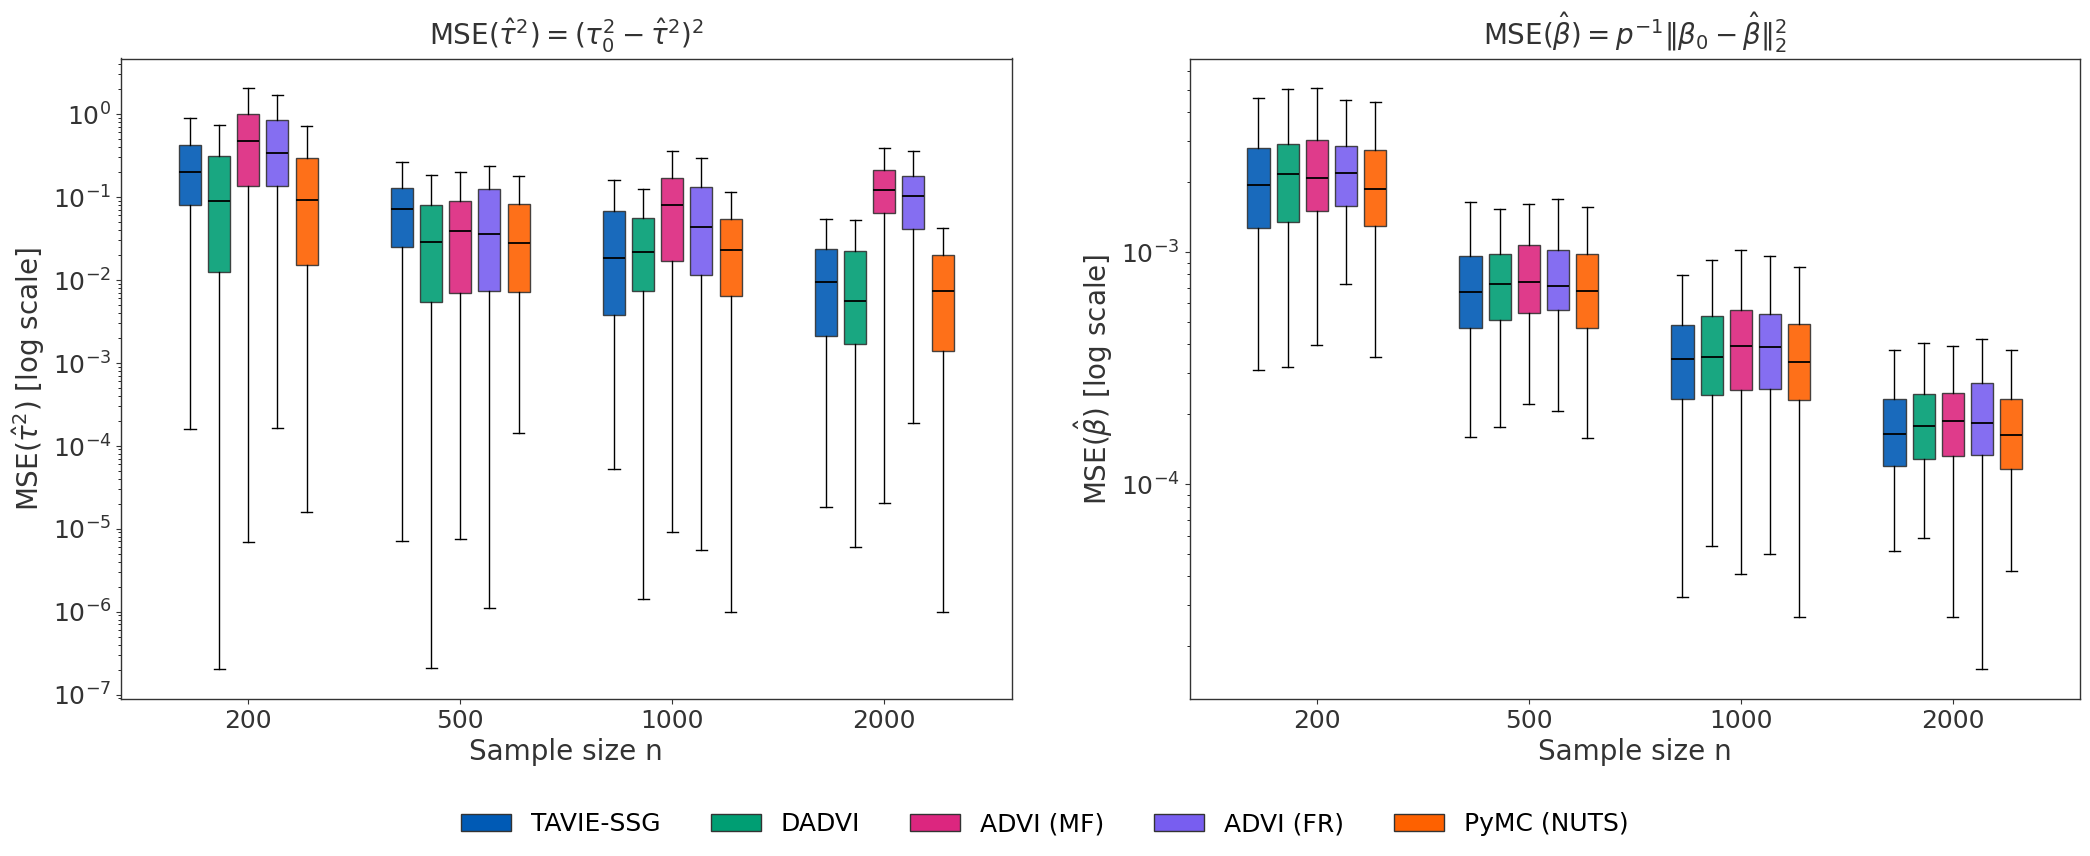

In [3]:
total_p = 9 # p = total_p - 1
p = 8
path2 = f"results_compete/Laplace_metrics_multi_n_p_{p}.pkl"

metrics_df_2 = pd.read_pickle(path2)
sample_sizes = metrics_df_2['n']

mse_beta_TAVIE = metrics_df_2['mse_beta_TAVIE']
mse_tau2_TAVIE = metrics_df_2['mse_tau2_TAVIE']
time_TAVIE = metrics_df_2['time_TAVIE']

mse_beta_DADVI = metrics_df_2['mse_beta_DADVI']
mse_tau2_DADVI = metrics_df_2['mse_tau2_DADVI']
time_DADVI = metrics_df_2['time_DADVI']

mse_beta_ADVI_mf = metrics_df_2['mse_beta_ADVI_mf']
mse_tau2_ADVI_mf = metrics_df_2['mse_tau2_ADVI_mf']
time_ADVI_mf = metrics_df_2['time_ADVI_mf']

mse_beta_ADVI_fr = metrics_df_2['mse_beta_ADVI_fr']
mse_tau2_ADVI_fr = metrics_df_2['mse_tau2_ADVI_fr']
time_ADVI_fr = metrics_df_2['time_ADVI_fr']

mse_beta_NUTS = metrics_df_2['mse_beta_NUTS']
mse_tau2_NUTS = metrics_df_2['mse_tau2_NUTS']
time_NUTS = metrics_df_2['time_NUTS']

runtime_arrays_n = [time_TAVIE, time_DADVI, time_ADVI_mf, time_ADVI_fr, time_NUTS]

methods = ['TAVIE', 'DADVI', 'ADVI MF', 'ADVI FR', 'NUTS']

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

methods  = ['TAVIE-SSG', 'DADVI', 'ADVI (MF)', 'ADVI (FR)', 'PyMC (NUTS)']

# nicer palette (see below for more options)
# colors = [
#     '#fee5d9',  # light rose
#     '#fcae91',  # warm peach
#     '#fb6a4a',  # vivid coral
#     '#ef3b2c',  # bright scarlet
#     '#cb181d',  # deep red
#     '#a01520'   # balanced crimson (less maroon, cleaner finish)
# ]

colors = [
    "#005AB5",    # vivid royal blue
   # "#FFB000",         # golden amber
    "#009E73",        # emerald green
    "#DC267F",    # vibrant magenta
    "#785EF0",    # electric violet
    "#FE6100",  # vivid orange
]


n_sizes  = len(sample_sizes)

# --- spacing controls ---
M             = len(methods)
group_spacing = 2.4     # gap between n-groups on the x-axis
method_step   = 0.33    # separation between methods within each group
box_width     = 0.25    # visual width of each box
centers       = np.arange(n_sizes) * group_spacing  # group centers for each n

fig, axes = plt.subplots(1, 2, figsize=(21, 8), facecolor='white')
median_kws = dict(color='black', linewidth=1.3)

# global style for axes
for ax in axes:
    ax.set_facecolor('white')
    for spine in ax.spines.values():
        spine.set_color('#333333')
        spine.set_linewidth(1.0)
    ax.tick_params(axis='both', colors='#333333', labelsize=18)
    #ax.grid(True, color='#DDDDDD', linestyle='--', linewidth=0.7, alpha=0.9)

# ---------- 1) τ² MSE (log scale) ----------
ax = axes[0]
tau2_arrays = [
    mse_tau2_TAVIE,
    mse_tau2_DADVI,
    mse_tau2_ADVI_mf,
    mse_tau2_ADVI_fr,
    mse_tau2_NUTS,
]

for j, arr in enumerate(tau2_arrays):
    # data for each n: arr[i, :] is the vector of replications
    data = [arr[i, :] for i in range(n_sizes)]
    positions = centers + (j - (M - 1) / 2) * method_step
    bp = ax.boxplot(
        data,
        positions=positions,
        widths=box_width,
        patch_artist=True,
        medianprops=median_kws,
        showfliers=False,           # often cleaner on log-scale
        whiskerprops=dict(linewidth=1.0),
        capprops=dict(linewidth=1.0)
    )
    for box in bp['boxes']:
        box.set(facecolor=colors[j], edgecolor='#333333', alpha=0.9)

ax.set_xticks(centers)
ax.set_xticklabels(sample_sizes, fontsize=18)
ax.set_yscale('log')
ax.set_xlabel('Sample size n', fontsize=20, color='#333333')
ax.set_ylabel(r'MSE($\hat{\tau}^2$) [log scale]', fontsize=20, color='#333333')
ax.set_title(r'$\mathrm{MSE}(\hat{\tau}^2) = (\tau_{0}^2 - \hat{\tau}^{2})^2$', fontsize=20, color='#333333', pad=10)
ax.set_xlim(centers[0] - group_spacing * 0.6, centers[-1] + group_spacing * 0.6)

# ---------- 2) β MSE (log scale) ----------
ax = axes[1]
beta_arrays = [
    mse_beta_TAVIE,
    mse_beta_DADVI,
    mse_beta_ADVI_mf,
    mse_beta_ADVI_fr,
    mse_beta_NUTS,
]

for j, arr in enumerate(beta_arrays):
    data = [arr[i, :] for i in range(n_sizes)]
    positions = centers + (j - (M - 1) / 2) * method_step
    bp = ax.boxplot(
        data,
        positions=positions,
        widths=box_width,
        patch_artist=True,
        medianprops=median_kws,
        showfliers=False,
        whiskerprops=dict(linewidth=1.0),
        capprops=dict(linewidth=1.0)
    )
    for box in bp['boxes']:
        box.set(facecolor=colors[j], edgecolor='#333333', alpha=0.9)

ax.set_xticks(centers)
ax.set_xticklabels(sample_sizes, fontsize=18)
ax.set_yscale('log')
ax.set_xlabel('Sample size n', fontsize=20, color='#333333')
ax.set_ylabel(r'MSE($\hat{\beta}$) [log scale]', fontsize=20, color='#333333')
ax.set_title(r'$\mathrm{MSE}(\hat{\beta}) = p^{-1}\|\beta_0 - \hat{\beta}\|_{2}^{2}$', fontsize=20, color='#333333', pad=10)
ax.set_xlim(centers[0] - group_spacing * 0.6, centers[-1] + group_spacing * 0.6)

# ---------- Common legend ----------
handles = [Patch(facecolor=colors[i], edgecolor='#333333', label=methods[i]) for i in range(M)]
fig.legend(handles=handles,
           loc='lower center',
           ncol=M,
           frameon=False,
           bbox_to_anchor=(0.5, -0.08),
           fontsize=18)

plt.tight_layout(rect=[0, 0.04, 1, 1])

plt.subplots_adjust(wspace=0.20, bottom=0.12, top=0.92)
fig.savefig(
    f'results_compete/plots/Laplace_MSE_boxplots_multi_n_p_{p}.pdf',  # choose your preferred path/name
    dpi=300,
    bbox_inches='tight',   # ensures no clipping of labels/legend
    facecolor='white'      # preserves clean white background
)
plt.show()

### Figure 24 in Supplementary Materials

See: `results_compete/plots/Laplace_SW_boxplots_multi_n_p_8_logscale.pdf`.

Saved figure to: results_compete/plots/Laplace_SW_boxplots_multi_n_p_8_logscale.pdf


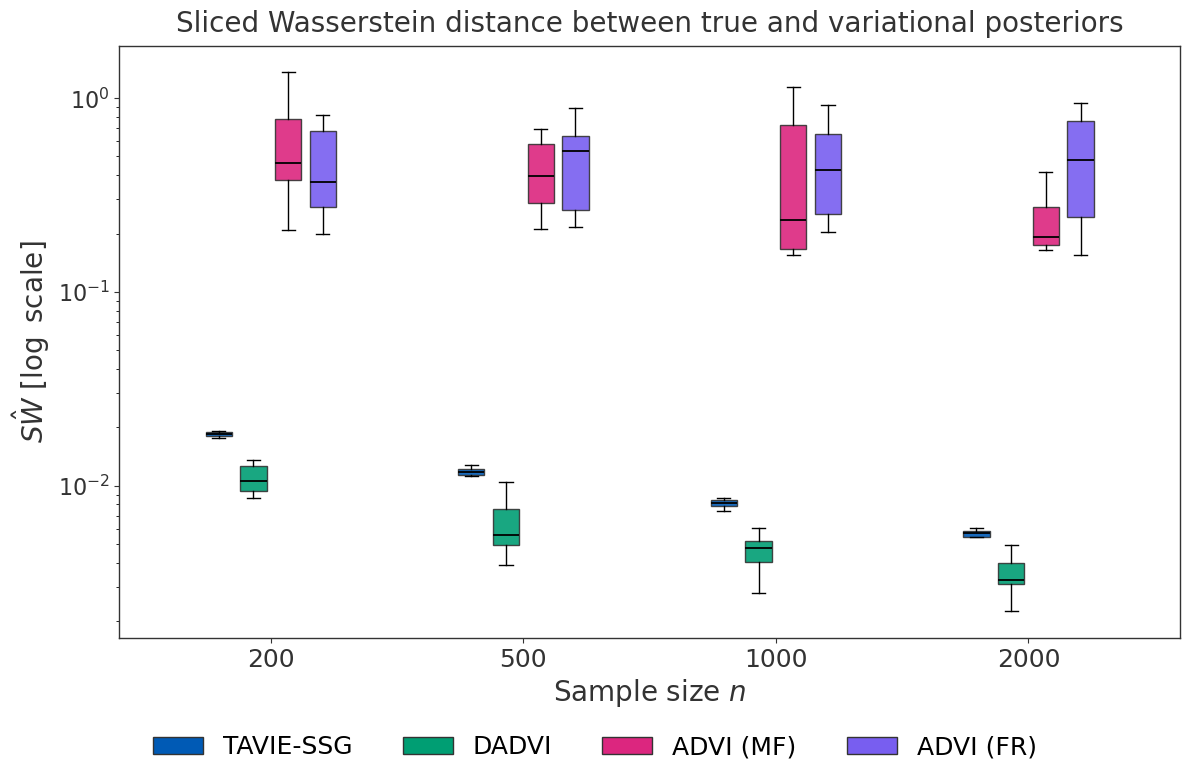

In [9]:
# ============================================================
# STYLED SW BOXPLOT (matching your MSE figure style)
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ------------------------------------------------------------
# Load and prepare the saved Sliced Wasserstein results
# ------------------------------------------------------------

# Defaults allow this cell to run after restarting the kernel.
p = globals().get("p", 8)
alpha = globals().get("alpha", 1.0)
output_dir = globals().get("output_dir", "results_compete")

sw_results_path = os.path.join(
    output_dir,
    f"sw_compare_methods_alpha_{alpha}_p_{p}.csv"
)

if not os.path.exists(sw_results_path):
    raise FileNotFoundError(
        f"Could not find the saved SW results:\n{sw_results_path}\n"
        "Run the SW simulation cell first or check p, alpha, and output_dir."
    )

results_df = pd.read_csv(sw_results_path)

sw_columns = [
    "sw_TAVIE",
    "sw_DADVI",
    "sw_ADVI_mf",
    "sw_ADVI_fr",
]

required_columns = ["n", "rep", "alpha", *sw_columns]
missing_columns = set(required_columns).difference(results_df.columns)

if missing_columns:
    raise ValueError(
        f"{sw_results_path} is missing the following required columns: "
        f"{sorted(missing_columns)}"
    )

# Convert the wide results table into long format for plotting.
plot_df = results_df.melt(
    id_vars=["n", "rep", "alpha"],
    value_vars=sw_columns,
    var_name="method",
    value_name="sliced_wasserstein"
)

plot_df["method"] = plot_df["method"].map({
    "sw_TAVIE": "TAVIE-SSG",
    "sw_DADVI": "DADVI",
    "sw_ADVI_mf": "ADVI (MF)",
    "sw_ADVI_fr": "ADVI (FR)",
})

# ------------------------------------------------------------
# Plot settings
# ------------------------------------------------------------

methods = [
    "TAVIE-SSG",
    "DADVI",
    "ADVI (MF)",
    "ADVI (FR)",
]

colors = [
    "#005AB5",  # TAVIE-SSG — vivid royal blue
    "#009E73",  # DADVI     — emerald green
    "#DC267F",  # ADVI (MF) — vibrant magenta
    "#785EF0",  # ADVI (FR) — electric violet
]

# Derive sample sizes directly from the SW results.
n_list = sorted(plot_df["n"].dropna().unique().tolist())
n_sizes = len(n_list)

# Spacing controls
M = len(methods)
group_spacing = 2.4
method_step = 0.33
box_width = 0.25

centers = np.arange(n_sizes) * group_spacing

fig, ax = plt.subplots(
    1,
    1,
    figsize=(12, 8),
    facecolor="white"
)

median_kws = dict(
    color="black",
    linewidth=1.3
)

# ------------------------------------------------------------
# Global axis style
# ------------------------------------------------------------

ax.set_facecolor("white")

for spine in ax.spines.values():
    spine.set_color("#333333")
    spine.set_linewidth(1.0)

ax.tick_params(
    axis="both",
    colors="#333333",
    labelsize=16
)

# ------------------------------------------------------------
# Collect data by method and sample size
# ------------------------------------------------------------

sw_arrays = []

for method in methods:
    method_arrays = []

    for n in n_list:
        vals = plot_df.loc[
            (plot_df["n"] == n)
            & (plot_df["method"] == method),
            "sliced_wasserstein"
        ].dropna().to_numpy(dtype=float)

        # A logarithmic axis requires strictly positive values.
        vals = vals[vals > 0]

        method_arrays.append(vals)

    sw_arrays.append(method_arrays)

# ------------------------------------------------------------
# Plot grouped boxplots
# ------------------------------------------------------------

for j, method_arrays in enumerate(sw_arrays):
    positions = (
        centers
        + (j - (M - 1) / 2) * method_step
    )

    bp = ax.boxplot(
        method_arrays,
        positions=positions,
        widths=box_width,
        patch_artist=True,
        medianprops=median_kws,
        showfliers=False,
        whiskerprops=dict(linewidth=1.0),
        capprops=dict(linewidth=1.0)
    )

    for box in bp["boxes"]:
        box.set(
            facecolor=colors[j],
            edgecolor="#333333",
            alpha=0.9
        )

# ------------------------------------------------------------
# Axis formatting
# ------------------------------------------------------------

ax.set_xticks(centers)
ax.set_xticklabels(n_list, fontsize=18)

ax.set_yscale("log")

ax.set_xlabel(
    r"Sample size $n$",
    fontsize=20,
    color="#333333"
)

ax.set_ylabel(
    r"$\hat{SW}$ [$\log$ scale]",
    fontsize=20,
    color="#333333"
)

ax.set_title(
    "Sliced Wasserstein distance between true and "
    "variational posteriors",
    fontsize=20,
    color="#333333",
    pad=10
)

ax.set_xlim(
    centers[0] - group_spacing * 0.6,
    centers[-1] + group_spacing * 0.6
)

# ------------------------------------------------------------
# Legend
# ------------------------------------------------------------

handles = [
    Patch(
        facecolor=colors[i],
        edgecolor="#333333",
        label=methods[i]
    )
    for i in range(M)
]

fig.legend(
    handles=handles,
    loc="lower center",
    ncol=M,
    frameon=False,
    bbox_to_anchor=(0.5, -0.02),
    fontsize=18
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.subplots_adjust(bottom=0.16, top=0.90)

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

plots_dir = os.path.join(output_dir, "plots")
os.makedirs(plots_dir, exist_ok=True)

figure_path = os.path.join(
    plots_dir,
    f"Laplace_SW_boxplots_multi_n_p_{p}_logscale.pdf"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

print(f"Saved figure to: {figure_path}")

plt.show()

### Experiment E2: fixed $n=1000$ and $p \in \{4, 9, 16, 21\}$

Recording $p^{-1}\lVert \beta_0 - \hat{\beta}\rVert_{2}^{2}$ and $(\tau_0^{2} - \hat{\tau}^{2})^2$. The results are stored in `results_compete/Laplace_metrics_multi_p_n_1000.pkl`.

In [ ]:
# ==== Experiment settings ====
n = 1000
total_p_values = [4,9,16,21]  # total_p_values = p_values + 1
p_values   = [3, 8, 15, 20]
tau2_true  = 3.0
num_reps   = 100

# Hyperparameters for BBVI full‐covariances
a, b = 0.025, 0.025

# Pre‐allocate storage
P = len(p_values)
mse_beta_TAVIE        = np.zeros((P, num_reps))
mse_tau2_TAVIE        = np.zeros((P, num_reps))
time_TAVIE            = np.zeros((P, num_reps))

mse_beta_DADVI        = np.zeros((P, num_reps))
mse_tau2_DADVI        = np.zeros((P, num_reps))
time_DADVI            = np.zeros((P, num_reps))

mse_beta_NUTS        = np.zeros((P, num_reps))
mse_tau2_NUTS        = np.zeros((P, num_reps))
time_NUTS            = np.zeros((P, num_reps))

mse_beta_ADVI_mf         = np.zeros((P, num_reps))
mse_tau2_ADVI_mf         = np.zeros((P, num_reps))
time_ADVI_mf             = np.zeros((P, num_reps))

mse_beta_ADVI_fr = np.zeros((P, num_reps))
mse_tau2_ADVI_fr = np.zeros((P, num_reps))
time_ADVI_fr     = np.zeros((P, num_reps))

# ==== Main loops over p and replicates ====
for i, p in enumerate(p_values):
    # Prior covariance for BBVI full-cov
    Sigma_prior = np.eye(p + 1)

    # Initialize TAVIE model once for this p
    laplace_tavie_model = TAVIE_loc_scale(family="laplace", fit_intercept=True)

    # Draw a fixed "true" beta for this p
    beta_true = np.random.normal(loc=0.0, scale=1.0, size=p+1)

    for rep in trange(num_reps, desc=f"p={p}"):
        np.random.seed(rep)
        # 1) Simulate data
        X      = np.random.normal(size=(n, p))
        X_bbvi = np.column_stack([np.ones(n), X])
        error  = np.random.laplace(loc=0.0, scale=1/np.sqrt(tau2_true), size=n)
        y      = X_bbvi @ beta_true + error

        # ---- TAVIE ----
        t0 = perf_counter()
        laplace_tavie_model.fit(X, y, verbose=False)
        time_TAVIE[i, rep] = perf_counter() - t0
        beta_est_TAVIE, tau2_est_TAVIE = laplace_tavie_model.get_TAVIE_means(verbose=False)
        mse_beta_TAVIE[i, rep] = np.mean((beta_est_TAVIE - beta_true)**2)
        mse_tau2_TAVIE[i, rep] = (tau2_est_TAVIE - tau2_true)**2

        # DADVI estimator
        laplace_dadvi_model = laplace_pymc_model(X_bbvi, y)
        t0 = perf_counter()
        laplace_dadvi_res = fit_pymc_dadvi_with_jax(laplace_dadvi_model, num_fixed_draws=30).get_posterior_means()
        time_DADVI[i, rep] = perf_counter() - t0
        beta_est_DADVI = laplace_dadvi_res['beta']
        tau2_est_DADVI = np.exp(laplace_dadvi_res['tau2_log__'])
        mse_beta_DADVI[i, rep] = np.mean((beta_est_DADVI - beta_true)**2)
        mse_tau2_DADVI[i, rep] = (tau2_est_DADVI - tau2_true)**2
    
        # NUTS estimator
        t0 = perf_counter()
        laplace_nuts_res = fit_NUTS_laplace(laplace_dadvi_model)
        time_NUTS[i, rep] = perf_counter() - t0
        beta_est_NUTS = laplace_nuts_res['beta']
        tau2_est_NUTS = laplace_nuts_res['tau2']
        mse_beta_NUTS[i, rep] = np.mean((beta_est_NUTS - beta_true)**2)
        mse_tau2_NUTS[i, rep] = (tau2_est_NUTS - tau2_true)**2

        # ---- ADVI mean-field ----
        t0 = perf_counter()
        res_diag = BBVI_Laplace_patience_best(
            X_bbvi, y,
            a=a, b=b,
            lr=1e-3,
            tol=1e-9,
            patience=1e4,
            verbose=False
        )
        time_ADVI_mf[i, rep] = perf_counter() - t0
        beta_d = res_diag['beta_mean']
        tau2_d = res_diag['tau2_mean']
        mse_beta_ADVI_mf[i, rep] = np.mean((beta_d - beta_true)**2)
        mse_tau2_ADVI_mf[i, rep] = (tau2_d - tau2_true)**2

        # ---- ADVI full-rank ----
        t0 = perf_counter()
        res_full = BBVI_Laplace_fullcov_AdamW_best(
            X_bbvi, y,
            Sigma_prior=Sigma_prior,
            a=a, b=b,
            lr=1e-3,
            tol=1e-9,
            patience=1e4,
            verbose=False
        )
        time_ADVI_fr[i, rep] = perf_counter() - t0

        beta_f = res_full['beta_mean']
        tau2_f = res_full['tau2_mean']
        mse_beta_ADVI_fr[i, rep] = np.mean((beta_f - beta_true)**2)
        mse_tau2_ADVI_fr[i, rep] = (tau2_f - tau2_true)**2

# saving the metrics
import pickle

# collect everything into a single dict
metrics_df = {
    'p'            :      p_values,
    'n'            :      n,
    'mse_beta_TAVIE':     mse_beta_TAVIE,
    'mse_tau2_TAVIE':     mse_tau2_TAVIE,
    'time_TAVIE':         time_TAVIE,
    'mse_beta_ADVI_mf':      mse_beta_ADVI_mf,
    'mse_tau2_ADVI_mf':      mse_tau2_ADVI_mf,
    'time_ADVI_mf':          time_ADVI_mf,
    'mse_beta_ADVI_fr':      mse_beta_ADVI_fr,
    'mse_tau2_ADVI_fr':      mse_tau2_ADVI_fr,
    'time_ADVI_fr':          time_ADVI_fr,
    'mse_beta_DADVI':      mse_beta_DADVI,
    'mse_tau2_DADVI':      mse_tau2_DADVI,
    'time_DADVI':          time_DADVI,
    'mse_beta_NUTS':      mse_beta_NUTS,
    'mse_tau2_NUTS':      mse_tau2_NUTS,
    'time_NUTS':          time_NUTS,
}

# write to disk
with open(f'results_compete/Laplace_metrics_multi_p_n_{n}.pkl', 'wb') as f:
    pickle.dump(metrics_df, f, protocol=pickle.HIGHEST_PROTOCOL)

### Figure 25 in Supplementary Materials

See: `results_compete/plots/Laplace_MSE_boxplots_multi_p_n_1000.pdf`.

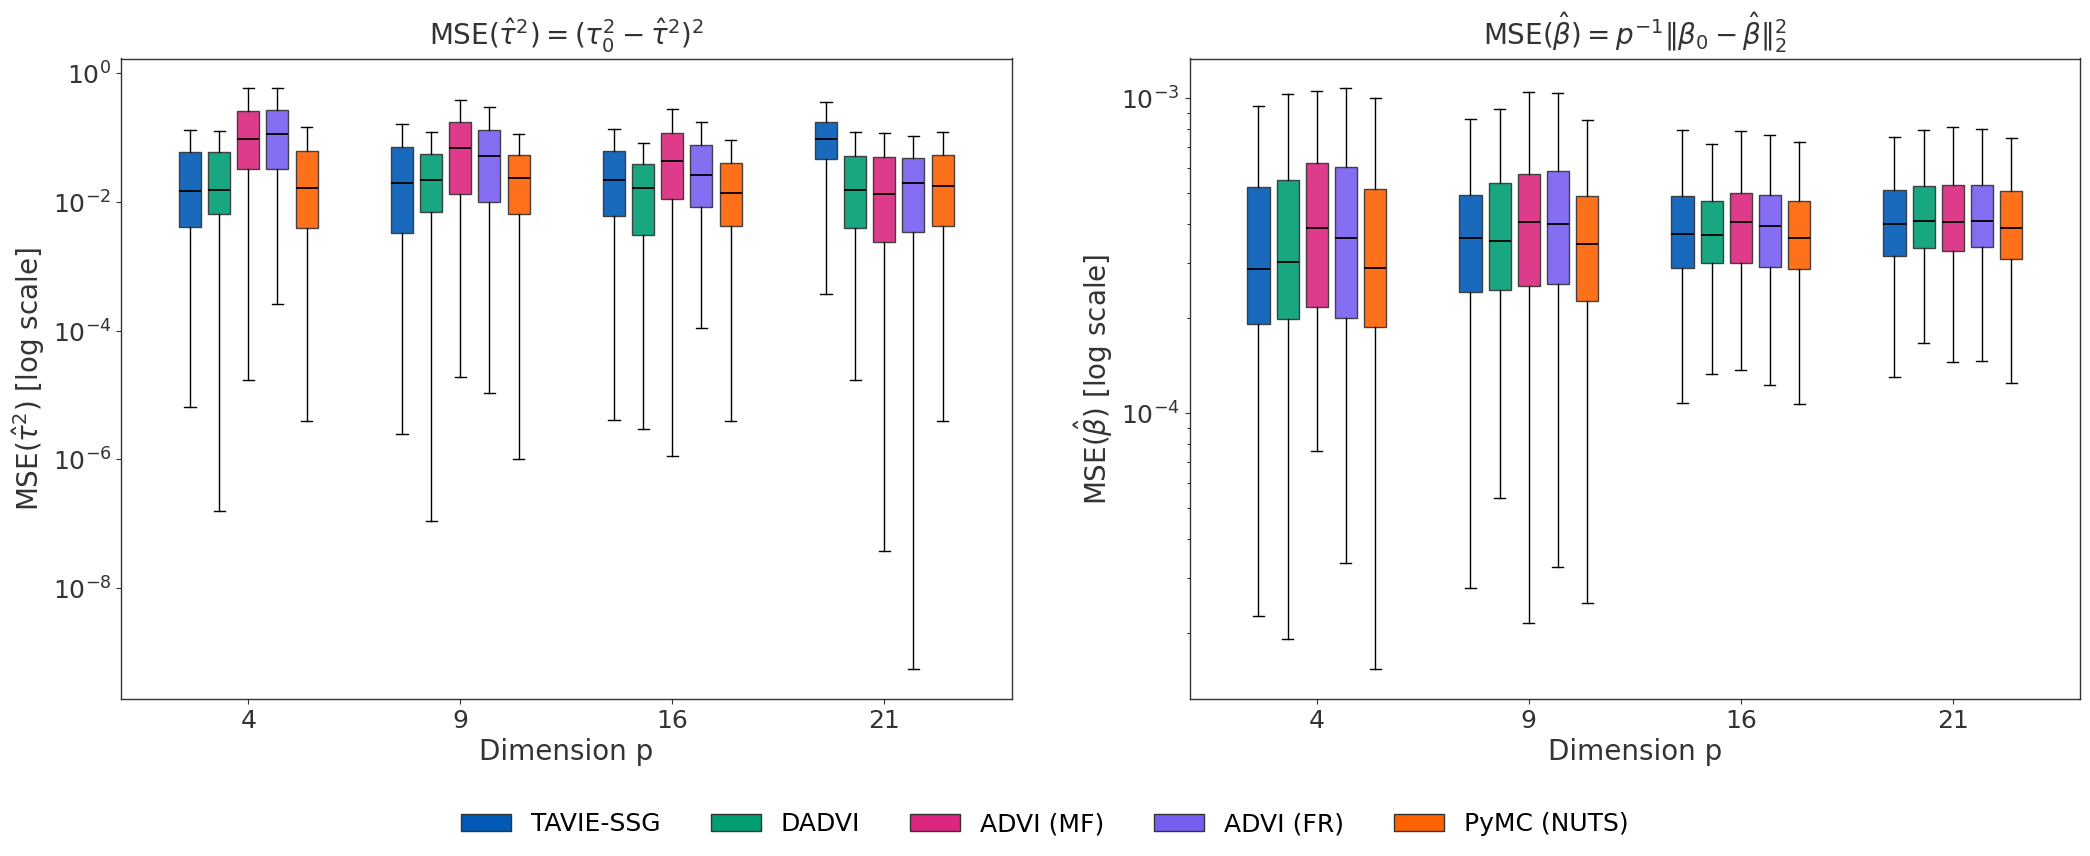

In [6]:
n = 1000
path3 = f'results_compete/Laplace_metrics_multi_p_n_{n}.pkl'

metrics_df_3 = pd.read_pickle(path3)
p_values = metrics_df_3['p']

mse_beta_TAVIE = metrics_df_3['mse_beta_TAVIE']
mse_tau2_TAVIE = metrics_df_3['mse_tau2_TAVIE']
time_TAVIE = metrics_df_3['time_TAVIE']

mse_beta_DADVI = metrics_df_3['mse_beta_DADVI']
mse_tau2_DADVI = metrics_df_3['mse_tau2_DADVI']
time_DADVI = metrics_df_3['time_DADVI']

mse_beta_ADVI_mf = metrics_df_3['mse_beta_ADVI_mf']
mse_tau2_ADVI_mf = metrics_df_3['mse_tau2_ADVI_mf']
time_ADVI_mf = metrics_df_3['time_ADVI_mf']

mse_beta_ADVI_fr = metrics_df_3['mse_beta_ADVI_fr']
mse_tau2_ADVI_fr = metrics_df_3['mse_tau2_ADVI_fr']
time_ADVI_fr = metrics_df_3['time_ADVI_fr']

mse_beta_NUTS = metrics_df_3['mse_beta_NUTS']
mse_tau2_NUTS = metrics_df_3['mse_tau2_NUTS']
time_NUTS = metrics_df_3['time_NUTS']

runtime_arrays_p = [time_TAVIE, time_DADVI, time_ADVI_mf, time_ADVI_fr, time_NUTS]

methods = ['TAVIE', 'DADVI', 'ADVI MF', 'ADVI FR', 'NUTS']

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

methods  = ['TAVIE-SSG', 'DADVI', 'ADVI (MF)', 'ADVI (FR)', 'PyMC (NUTS)']

# nicer palette (see below for more options)
colors = [
    "#005AB5",   # TAVIE-SSG  — vivid royal blue
    "#009E73",   # DADVI      — emerald green
    "#DC267F",   # ADVI (MF)  — vibrant magenta
    "#785EF0",   # ADVI (FR)  — electric violet
    "#FE6100",   # PyMC (NUTS)— vivid orange
]

p_sizes  = len(p_values)

# --- spacing controls ---
M             = len(methods)
group_spacing = 2.4     # gap between n-groups on the x-axis
method_step   = 0.33    # separation between methods within each group
box_width     = 0.25    # visual width of each box
centers       = np.arange(p_sizes) * group_spacing  # group centers for each n

fig, axes = plt.subplots(1, 2, figsize=(21, 8), facecolor='white')
median_kws = dict(color='black', linewidth=1.3)

# global style for axes
for ax in axes:
    ax.set_facecolor('white')
    for spine in ax.spines.values():
        spine.set_color('#333333')
        spine.set_linewidth(1.0)
    ax.tick_params(axis='both', colors='#333333', labelsize=18)
    #ax.grid(True, color='#DDDDDD', linestyle='--', linewidth=0.7, alpha=0.9)

# ---------- 1) τ² MSE (log scale) ----------
ax = axes[0]
tau2_arrays = [
    mse_tau2_TAVIE,
    mse_tau2_DADVI,
    mse_tau2_ADVI_mf,
    mse_tau2_ADVI_fr,
    mse_tau2_NUTS,
]

for j, arr in enumerate(tau2_arrays):
    # data for each n: arr[i, :] is the vector of replications
    data = [arr[i, :] for i in range(p_sizes)]
    positions = centers + (j - (M - 1) / 2) * method_step
    bp = ax.boxplot(
        data,
        positions=positions,
        widths=box_width,
        patch_artist=True,
        medianprops=median_kws,
        showfliers=False,           # often cleaner on log-scale
        whiskerprops=dict(linewidth=1.0),
        capprops=dict(linewidth=1.0)
    )
    for box in bp['boxes']:
        box.set(facecolor=colors[j], edgecolor='#333333', alpha=0.9)

ax.set_xticks(centers)
ax.set_xticklabels(np.array(p_values)+1, fontsize=18)
ax.set_yscale('log')
ax.set_xlabel('Dimension p', fontsize=20, color='#333333')
ax.set_ylabel(r'MSE($\hat{\tau}^2$) [log scale]', fontsize=20, color='#333333')
ax.set_title(r'$\mathrm{MSE}(\hat{\tau}^2) = (\tau_0^2 - \hat{\tau}^{2})^2$', fontsize=20, color='#333333', pad=10)
ax.set_xlim(centers[0] - group_spacing * 0.6, centers[-1] + group_spacing * 0.6)

# ---------- 2) β MSE (log scale) ----------
ax = axes[1]
beta_arrays = [
    mse_beta_TAVIE,
    mse_beta_DADVI,
    mse_beta_ADVI_mf,
    mse_beta_ADVI_fr,
    mse_beta_NUTS,
]

for j, arr in enumerate(beta_arrays):
    data = [arr[i, :] for i in range(p_sizes)]
    positions = centers + (j - (M - 1) / 2) * method_step
    bp = ax.boxplot(
        data,
        positions=positions,
        widths=box_width,
        patch_artist=True,
        medianprops=median_kws,
        showfliers=False,
        whiskerprops=dict(linewidth=1.0),
        capprops=dict(linewidth=1.0)
    )
    for box in bp['boxes']:
        box.set(facecolor=colors[j], edgecolor='#333333', alpha=0.9)

ax.set_xticks(centers)
ax.set_xticklabels(np.array(p_values) + 1, fontsize=18)
ax.set_yscale('log')
ax.set_xlabel('Dimension p', fontsize=20, color='#333333')
ax.set_ylabel(r'MSE($\hat{\beta}$) [log scale]', fontsize=20, color='#333333')
ax.set_title(r'$\mathrm{MSE}(\hat{\beta}) = p^{-1}\|\beta_0 - \hat{\beta}\|_{2}^{2}$', fontsize=20, color='#333333', pad=10)
ax.set_xlim(centers[0] - group_spacing * 0.6, centers[-1] + group_spacing * 0.6)

# ---------- Common legend ----------
handles = [Patch(facecolor=colors[i], edgecolor='#333333', label=methods[i]) for i in range(M)]
fig.legend(handles=handles,
           loc='lower center',
           ncol=M,
           frameon=False,
           bbox_to_anchor=(0.5, -0.08),
           fontsize=18)

plt.tight_layout(rect=[0, 0.04, 1, 1])

plt.subplots_adjust(wspace=0.20, bottom=0.12, top=0.92)
fig.savefig(
    f'results_compete/plots/Laplace_MSE_boxplots_multi_p_n_{n}.pdf',  # choose your preferred path/name
    dpi=300,
    bbox_inches='tight',   # ensures no clipping of labels/legend
    facecolor='white'      # preserves clean white background
)
plt.show()


### Figure 26 in Supplementary Materials

See: `results_compete/plots/runtime_Laplace_multi_n_multi_p.pdf`.

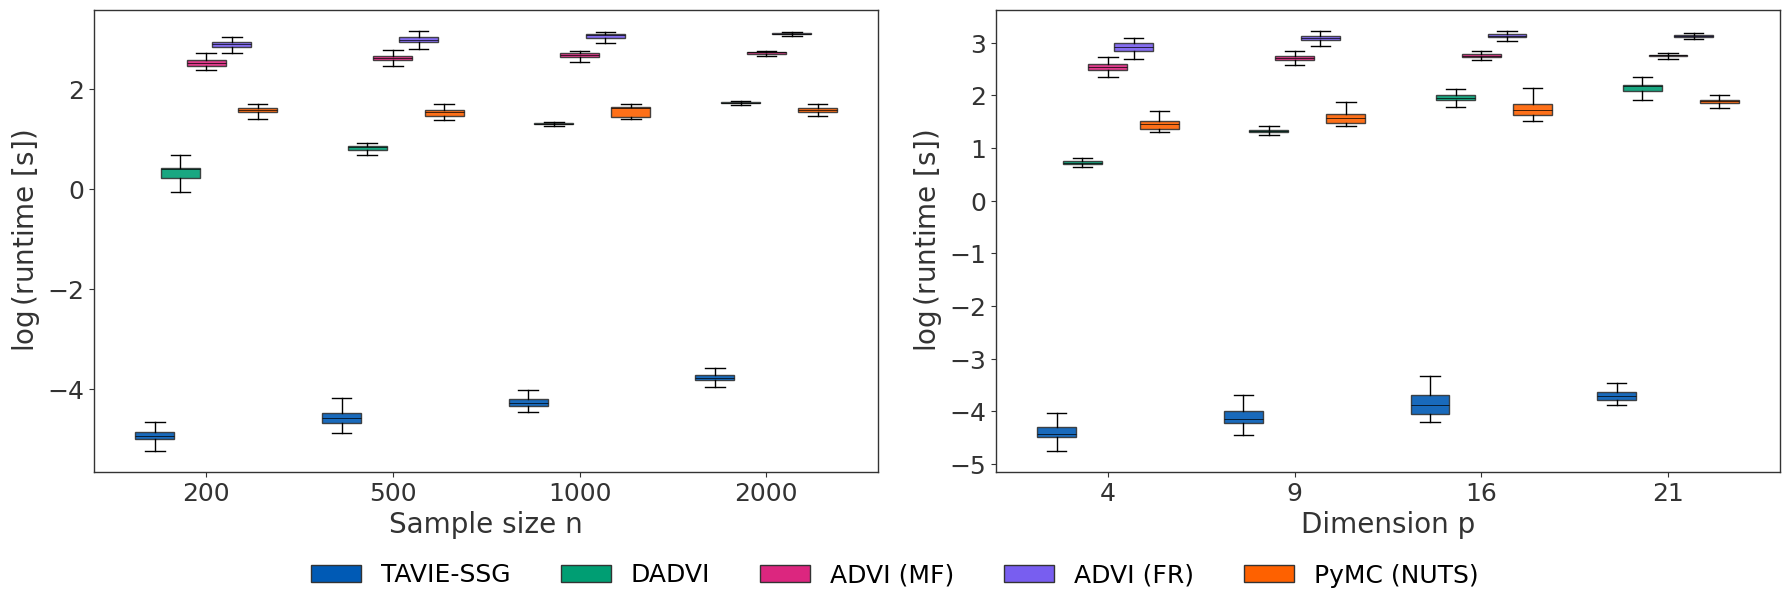

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

eps = 1e-16
methods = ['TAVIE-SSG', 'DADVI', 'ADVI (MF)', 'ADVI (FR)', 'PyMC (NUTS)']

colors_runtime = [
    "#005AB5",   # TAVIE-SSG  — vivid royal blue
    "#009E73",   # DADVI      — emerald green
    "#DC267F",   # ADVI (MF)  — vibrant magenta
    "#785EF0",   # ADVI (FR)  — electric violet
    "#FE6100",   # PyMC (NUTS)— vivid orange
]


# ----- Data arrays -----
#runtime_arrays_n = [time_TAVIE, time_DADVI, time_ADVI_mf, time_ADVI_fr, time_NUTS]
#runtime_arrays_p = [time_TAVIE, time_DADVI, time_ADVI_mf, time_ADVI_fr, time_NUTS]

n_sizes = len(sample_sizes)
p_sizes = len(p_values)
M = len(methods)
group_spacing = 2.4
method_step = 0.33
box_width = 0.50#0.25

# --- Create 1x2 figure ---
fig, axes = plt.subplots(1, 2, figsize=(18, 6), facecolor='white')
median_kws = dict(color='black', linewidth=0.5)

# ===============================================================
# Left panel: runtime vs sample size n
# ===============================================================
ax = axes[0]
centers = np.arange(n_sizes) * group_spacing

for j, arr in enumerate(runtime_arrays_n):
    data = [np.log(np.clip(arr[i, :], eps, None)) for i in range(n_sizes)]
    positions = centers + (j - (M - 1) / 2) * method_step
    bp = ax.boxplot(
        data, positions=positions, widths=box_width, patch_artist=True,
        medianprops=median_kws, showfliers=False,
        whiskerprops=dict(linewidth=1.0), capprops=dict(linewidth=1.0)
    )
    for box in bp['boxes']:
        box.set(facecolor=colors_runtime[j], edgecolor='#333333', alpha=0.9)

ax.set_xticks(centers)
ax.set_xticklabels(sample_sizes, fontsize=18)
ax.set_xlabel('Sample size n', fontsize=20, color='#333333')
ax.set_ylabel(r'$\log$(runtime [s])', fontsize=20, color='#333333')
ax.set_xlim(centers[0] - group_spacing * 0.6, centers[-1] + group_spacing * 0.6)
ax.tick_params(axis='both', colors='#333333', labelsize=18)
for spine in ax.spines.values():
    spine.set_color('#333333'); spine.set_linewidth(1.0)

# ===============================================================
# Right panel: runtime vs dimension p
# ===============================================================
ax = axes[1]
centers = np.arange(p_sizes) * group_spacing

for j, arr in enumerate(runtime_arrays_p):
    data = [np.log(np.clip(arr[i, :], eps, None)) for i in range(p_sizes)]
    positions = centers + (j - (M - 1) / 2) * method_step
    bp = ax.boxplot(
        data, positions=positions, widths=box_width, patch_artist=True,
        medianprops=median_kws, showfliers=False,
        whiskerprops=dict(linewidth=1.0), capprops=dict(linewidth=1.0)
    )
    for box in bp['boxes']:
        box.set(facecolor=colors_runtime[j], edgecolor='#333333', alpha=0.9)

ax.set_xticks(centers)
ax.set_xticklabels(np.array(p_values)+1, fontsize=18)
ax.set_xlabel('Dimension p', fontsize=20, color='#333333')
ax.set_ylabel(r'$\log$(runtime [s])', fontsize=20, color='#333333')
ax.set_xlim(centers[0] - group_spacing * 0.6, centers[-1] + group_spacing * 0.6)
ax.tick_params(axis='both', colors='#333333', labelsize=18)
for spine in ax.spines.values():
    spine.set_color('#333333'); spine.set_linewidth(1.0)

# ===============================================================
# Common legend (below both panels)
# ===============================================================
handles = [Patch(facecolor=colors_runtime[i], edgecolor='#333333', label=methods[i])
           for i in range(M)]
fig.legend(handles=handles, loc='lower center', ncol=M, frameon=False,
           fontsize=18, bbox_to_anchor=(0.5, -0.08))

plt.tight_layout(rect=[0, 0.05, 1, 1])
fig.subplots_adjust(wspace=0.15, bottom=0.15, top=0.92)

fig.savefig('results_compete/plots/runtime_Laplace_multi_n_multi_p.pdf',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


### ELBO plots for TAVIE-SSG, ADVI (MF), and ADVI (FR): Figure 27 in Supplementary Section M.1

See: `results_compete/plots/Laplace_ELBO_n_1000_p_8.pdf`

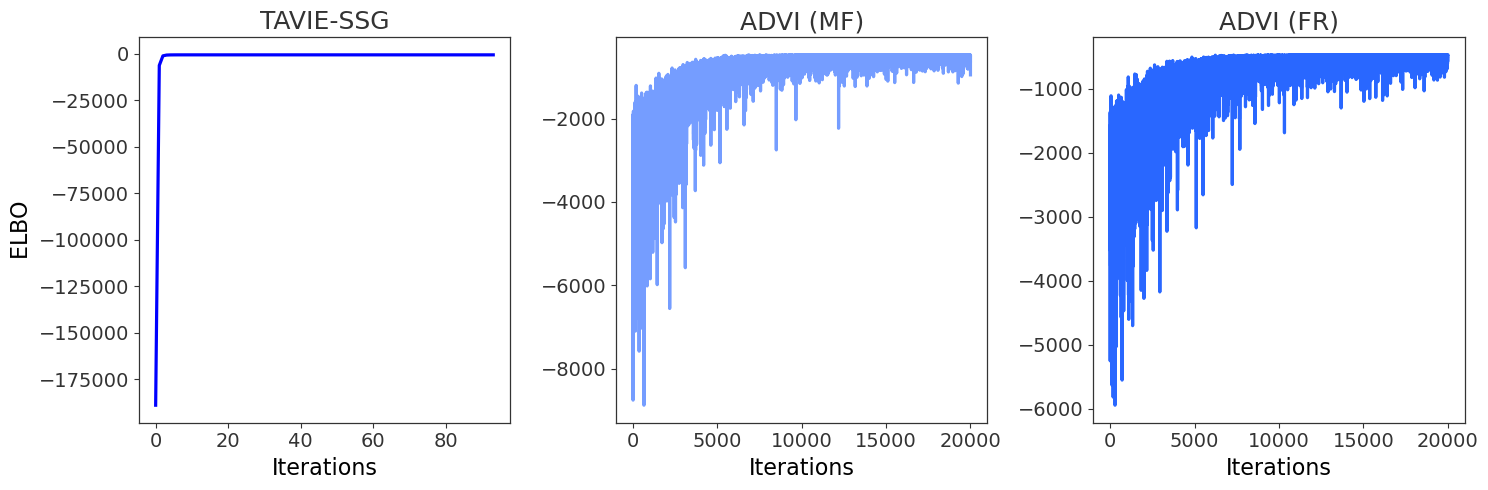

In [ ]:
# ==== Experiment settings ====
total_p = 9  # total_p = p + 1
p = 8
tau2_true = 3.0
n = 1000

# True beta vector
beta_true = np.random.normal(loc=0.0, scale=1.0, size=p+1)

# Prior for full‐cov BBVI
Sigma_prior = np.eye(p + 1)
a, b = 0.025, 0.025

# Initialize TAVIE once
laplace_tavie_model = TAVIE_loc_scale(family="laplace", fit_intercept=True)

X = np.random.normal(size=(n, p))
X_bbvi = np.column_stack((np.ones(n), X))
error =  np.random.laplace(loc=0.0, scale=1/np.sqrt(tau2_true), size=n)
y = beta_true[0] + X @ beta_true[1:len(beta_true)] + error

# ---- TAVIE ----
laplace_tavie_model.fit(X, y, verbose=False)

# ADVI mean-field estimator
res2 = BBVI_Laplace_patience_best(
            X_bbvi, y,
            a=a, b=b,
            lr=1e-3,
            tol=1e-9,
            patience=1e4,
            verbose=False
        )

# ADVI full-rank estimator
res3 = BBVI_Laplace_fullcov_AdamW_best(
            X_bbvi, y,
            Sigma_prior=Sigma_prior,
            a=a, b=b,
            lr=1e-3,
            tol=1e-9,
            patience=1e4,
            verbose=False
        )

tavie_elbo = laplace_tavie_model.get_elbo()
advi_mf_elbo = res2['elbo_hist']
advi_fr_elbo = res3['elbo_hist']

fig, axes = plt.subplots(1, 3, figsize=(15, 5), facecolor='white')
colors = [
    'blue',  # bright aqua
    '#759DFF',  # turquoise blue
    '#2967FF'   # strong deep blue
]
axes[0].plot(tavie_elbo, color=colors[0], linewidth=2.3)
axes[0].set_title(r'TAVIE-SSG', fontsize=18, color='#333333')
axes[0].set_xlabel('Iterations', fontsize=16)
axes[0].set_ylabel(r'$\mathsf{ELBO}$', fontsize=16)

axes[1].plot(advi_mf_elbo, color=colors[1], linewidth=2.3)
axes[1].set_title(r'ADVI (MF)', fontsize=18, color='#333333')
axes[1].set_xlabel('Iterations', fontsize=16)

axes[2].plot(advi_fr_elbo, color=colors[2], linewidth=2.3)
axes[2].set_title(r'ADVI (FR)', fontsize=18, color='#333333')
axes[2].set_xlabel('Iterations', fontsize=16)

# --- Shared styling ---
for ax in axes:
    #ax.grid(True, linestyle='--', linewidth=0.6, alpha=0.7)
    for spine in ax.spines.values():
        spine.set_color('#333333')
        spine.set_linewidth(0.9)
    ax.tick_params(axis='both', labelsize=14, colors='#333333')

plt.tight_layout()
#fig.suptitle(r'$\mathsf{ELBO}$ Convergence Trajectories', fontsize=17, color='#333333', y=1.03)

# Save high-resolution figure
fig.savefig(f'results_compete/plots/Laplace_ELBO_n_{n}_p_{p}.pdf',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
